# Задача регрессии

В случае задач машинного обучения с учителем существует какое-то количество размеченных данных, данных, для которых определен корректный ответ и корректное предсказание. Мы пытаемся обучить нашу модель на этих данных и потом сделать предсказание на новых данных, которых мы еще не видели. Далее когда поступают новые данные, не размеченные, наша обученная модель пытается предсказать для них ответ.

В этом разделе мы посмотрим на одну из задач машинного обучения с учителем - это задача регрессии.

**Задача регрессии** (прогнозирования) – построение модели, способной предсказывать численную величину на основе набора признаков объекта.

**Регрессия. Постановка задачи.**

Есть обучающая выборка, в которой представлены объекты в виде из признакового описания (вектор признаков) и значения целевой переменной (непрерывная переменная).

Алгоритм регрессии дл каждого нового объекта (его признакового описания) прогнозирует значение целевой переменной.

**Ответ в задачах регресии является числовым из непрерывного диапазона, в отличии от задач классификации, где ответ дискретный.**

# Линейная регрессия

Самый простой способ посчитать регрессиию, предположить, что есть некая линейная зависимость от признаков.

$$f_{w,b}(x) = wx + b$$

In [43]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Мы ещё отдельно разберём как считать ошибки, но, упрощённо говоря, достаточно считать квадрат разности между настоящими и посчитанными значениями.

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2$$

Подбирать параметры поможет градиентный спуск.

$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}$$

$$b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

Для него нужно посчитать производные ошибки по параметрам.

$$
\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(X^{(i)}) - y^{(i)})
$$

$$
\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(X^{(i)}) - y^{(i)})X^{(i)}
$$

In [44]:
class LinearRegression():

    def __init__(self, learning_rate, iterations) -> None:
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.b = None

    def fit(self, X: np.ndarray, Y: np.ndarray, step: int=1e2) -> None:
        self.weights = np.zeros(X.shape[1])
        self.b = 0

        for i in range(self.iterations + 1):
            self.update_weights(X, Y)
            if i % step == 0:
                print(f"Iter: {i}, MSE: {self.MSE(self.predict(X), Y)}")

    def update_weights(self, X: np.ndarray, Y: np.ndarray) -> None:
        F = self.predict(X)
        m = X.shape[0]
        self.weights -= self.lr * (1 / m) * np.dot(X.T, (F - Y))
        self.b -= self.lr * (1 / m) * np.sum(F - Y)

    def predict(self, X: np.ndarray) -> float:
        return np.sum(self.weights * X, axis=1) + self.b
    
    @staticmethod
    def MSE(X: np.ndarray, Y: np.ndarray) -> float:
        if X.shape != Y.shape:
            raise Exception(f"X shape: {X.shape} != Y shape: {Y.shape}")
        return (1 / (2 * X.shape[0])) * sum((X - Y)**2)

Iter: 0, MSE: 1405519856.622921
Iter: 100, MSE: 60015330.8875577
Iter: 200, MSE: 46074595.44071234
Iter: 300, MSE: 36767665.60250197
Iter: 400, MSE: 30554295.917406134
Iter: 500, MSE: 26406208.039364137
Iter: 600, MSE: 23636916.34805642
Iter: 700, MSE: 21788118.372453745
Iter: 800, MSE: 20553848.264569823
Iter: 900, MSE: 19729841.142472435
Iter: 1000, MSE: 19179728.381148834


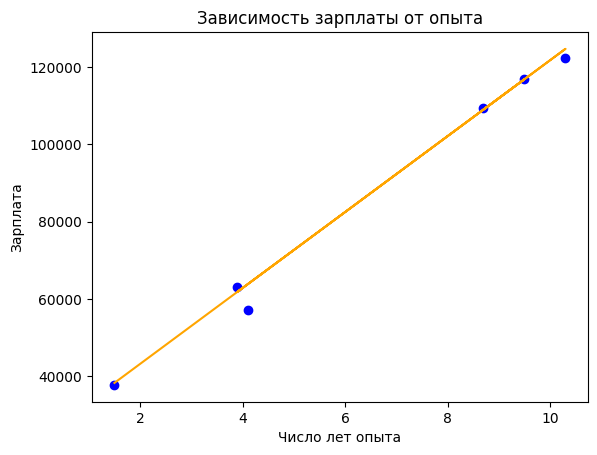

In [45]:
df = pd.read_csv( "salary_data.csv" )

X = df.iloc[:,:-1].values
Y = df.iloc[:,1].values

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0 )
model = LinearRegression(iterations = 1000, learning_rate = 0.01)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)


plt.scatter(X_test, Y_test, color = 'blue')
plt.plot(X_test, Y_pred, color = 'orange')
plt.title('Зависимость зарплаты от опыта')
plt.xlabel('Число лет опыта')
plt.ylabel('Зарплата')

plt.show()